# Detección de vehículos mediante clustering de datos LIDAR

**Objetivo:** a partir de una nube de puntos capturada por un LIDAR de infraestructura,
detectar cuántos vehículos hay presentes, aplicando:
1. Preprocesado (limpieza, eliminación de suelo, aislamiento de la zona de carretera)
2. Clustering con DBSCAN + filtrado por criterios físicos (tamaño, forma, apoyo en el suelo)
3. Clustering con K-Means (configurado según el resultado de DBSCAN)

## 1. Librerías utilizadas

- **pandas**: cargar el CSV como tabla y filtrar/explorar datos fácilmente.
- **numpy**: operaciones numéricas vectorizadas (arrays, álgebra vectorial).
- **matplotlib**: gráficas estáticas para exploración inicial.
- **plotly**: visualización 3D interactiva embebida en el notebook.
- **open3d**: detección automática del plano del suelo (RANSAC).
- **scikit-learn**: algoritmos de clustering `DBSCAN` y `KMeans`, y `NearestNeighbors`
  (para justificar el parámetro `eps` de DBSCAN).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import open3d as o3d
from sklearn.cluster import DBSCAN, KMeans
from sklearn.neighbors import NearestNeighbors

## 2. Carga y limpieza de datos

Cargamos el CSV y descartamos los puntos inválidos: disparos del láser sin retorno
(`range == 0`) y outliers de rango excesivo (posible ruido).

In [2]:
df = pd.read_csv('data/1_coche.csv')
print("Puntos totales:", len(df))

Puntos totales: 131072


In [7]:
df.head()

,x,y,z,intensity,t,reflectivity,ring,ambient,range
0,-0.000000,0.000000,0.000000,0.0,1181241184,0,0,0,0
1,-0.000000,0.000000,0.000000,16.0,0,0,0,1470,0
2,-0.000000,0.000000,0.000000,13.0,49720,0,0,1025,0
3,-13.000649,2.733196,13.144561,14.0,99080,3,0,649,18670
4,-12.894675,2.793606,13.054574,12.0,150920,2,0,702,18542


In [6]:
df.describe()

,x,y,z,intensity,t,reflectivity,ring,ambient,range
count,131072.000000,131072.000000,131072.000000,131072.000000,1.310720e+05,131072.000000,131072.000000,131072.000000,131072.000000
mean,0.086490,2.395804,0.022339,80.008461,5.968601e+08,4.616554,63.500000,1006.336197,4447.366188
std,6.073837,2.846077,3.318614,182.658128,5.844056e+08,10.627313,36.949431,1517.728301,6480.634664
min,-95.591150,-3.026484,-31.093044,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000
25%,0.000000,-0.000000,-0.000000,0.000000,1.249228e+07,0.000000,31.750000,0.000000,0.000000
50%,0.000000,-0.000000,0.000000,0.500000,6.030953e+08,0.000000,63.500000,126.500000,0.000000
75%,0.000000,5.619644,0.000000,109.000000,1.181241e+09,6.000000,95.250000,1564.000000,7694.000000
max,167.198500,15.588192,29.421364,2819.000000,1.181241e+09,255.000000,127.000000,65535.000000,168365.000000


### 2.1 Detección y limpieza de puntos inválidos

El sensor genera una fila por cada disparo láser, incluso sin retorno (`range == 0`).
Comprobamos cuántos puntos son inválidos y los descartamos, junto con outliers de
rango excesivo.

In [8]:
puntos_invalidos = (df['range'] == 0).sum()
print(f"Puntos inválidos (range=0): {puntos_invalidos} ({puntos_invalidos/len(df)*100:.1f}%)")

df_limpio = df[(df['range'] > 0) & (df['range'] < 30000)].copy()
print(f"Puntos tras limpiar: {len(df_limpio)}")

Puntos inválidos (range=0): 74025 (56.5%)
Puntos tras limpiar: 56568


## 3. Primera visualización

Vista rápida en 2D para orientarnos antes de aplicar ningún algoritmo.

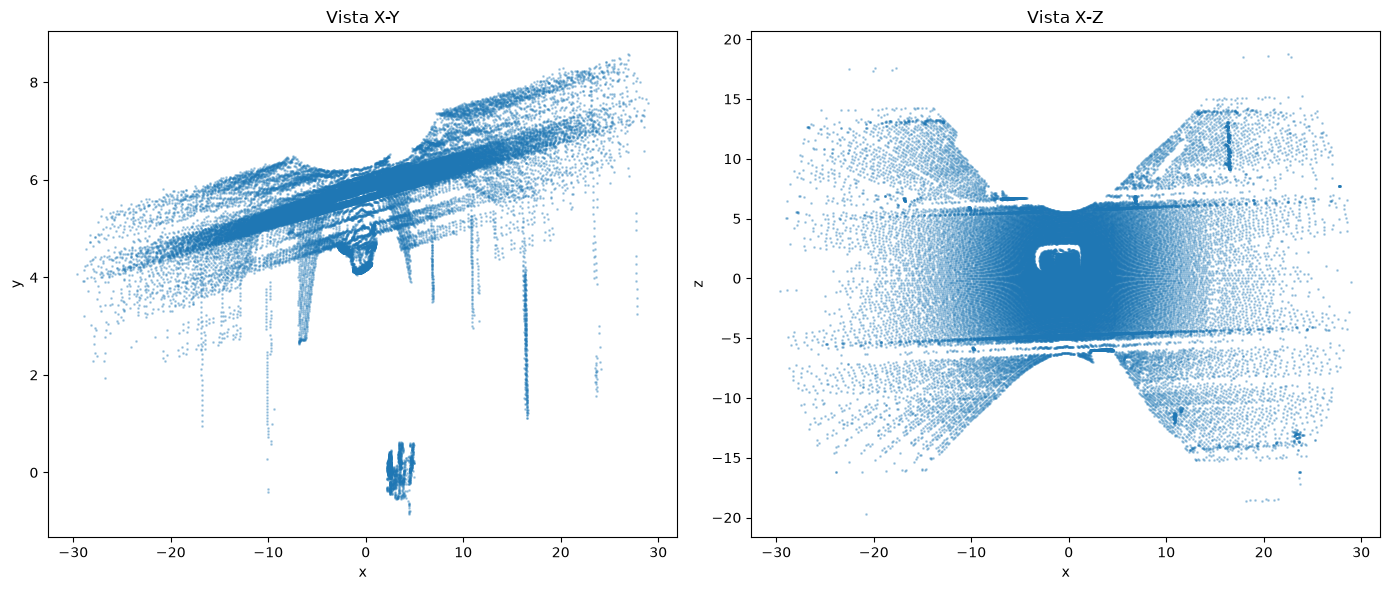

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].scatter(df_limpio['x'], df_limpio['y'], s=1, alpha=0.3)
axes[0].set_title('Vista X-Y'); axes[0].set_xlabel('x'); axes[0].set_ylabel('y')
axes[1].scatter(df_limpio['x'], df_limpio['z'], s=1, alpha=0.3)
axes[1].set_title('Vista X-Z'); axes[1].set_xlabel('x'); axes[1].set_ylabel('z')
plt.tight_layout()
plt.show()

## 4. Eliminación del suelo

El suelo es un plano, pero inclinado respecto a los ejes del sensor. Usamos RANSAC
(Open3D) para encontrar su ecuación automáticamente, sea cual sea su orientación.

In [10]:
puntos_xyz = df_limpio[['x', 'y', 'z']].to_numpy()

nube = o3d.geometry.PointCloud()
nube.points = o3d.utility.Vector3dVector(puntos_xyz)

plane_model, inliers = nube.segment_plane(
    distance_threshold=0.15,
    ransac_n=3,
    num_iterations=1000
)

suelo = puntos_xyz[inliers]
no_suelo = np.delete(puntos_xyz, inliers, axis=0)

a, b, c, d = plane_model
print(f"Plano: {a:.4f}x + {b:.4f}y + {c:.4f}z + {d:.4f} = 0")
print(f"Suelo: {len(suelo)} puntos | No suelo: {len(no_suelo)} puntos")

Plano: -0.0605x + 0.9972y + 0.0435z + -5.7948 = 0
Suelo: 40408 puntos | No suelo: 16160 puntos


### 4.1 Función reutilizable de visualización 3D

Para no repetir el mismo bloque de plotly cada vez, definimos una función una única vez.

In [11]:
def plot_3d(grupos, titulo=""):
    """
    grupos: diccionario {nombre: (array_de_puntos, color)}
    """
    fig = go.Figure()
    for nombre, (puntos, color) in grupos.items():
        fig.add_trace(go.Scatter3d(
            x=puntos[:, 0], y=puntos[:, 1], z=puntos[:, 2],
            mode='markers',
            marker=dict(size=2, color=color, opacity=0.6),
            name=nombre
        ))
    fig.update_layout(
        scene=dict(xaxis_title='x', yaxis_title='y', zaxis_title='z',
                    aspectmode='data'),
        title=titulo,
        width=900, height=700,
        margin=dict(l=0, r=0, b=0, t=30)
    )
    fig.show()

plot_3d({'Suelo': (suelo, 'tan'), 'No suelo': (no_suelo, 'red')}, "Suelo vs. resto")

### 4.2 Aislar la carretera real dentro del suelo

RANSAC nos da TODO lo que es coplanar con el suelo, incluyendo superficies físicamente
desconectadas de la carretera (una acera al otro lado de una valla, por ejemplo).
Aplicamos DBSCAN sobre los puntos de suelo para separar esas superficies, y nos
quedamos con la más grande como "la carretera real".

In [12]:
db_suelo = DBSCAN(eps=0.5, min_samples=10)
labels_suelo = db_suelo.fit_predict(suelo)

tamanos = pd.Series(labels_suelo[labels_suelo != -1]).value_counts()
cluster_carretera = tamanos.idxmax()
carretera = suelo[labels_suelo == cluster_carretera]

print(f"Superficies de suelo encontradas: {len(tamanos)}")
print(f"Carretera real: cluster {cluster_carretera}, {len(carretera)} puntos (de {len(suelo)} totales)")

Superficies de suelo encontradas: 17
Carretera real: cluster 1, 38299 puntos (de 40408 totales)


In [14]:
es_otra_superficie = (labels_suelo != cluster_carretera) & (labels_suelo != -1)

resto_suelo = suelo[es_otra_superficie]
carretera = suelo[~es_otra_superficie]  # cluster principal + ruido disperso, todo cuenta como carretera

plot_3d({
    'Carretera': (carretera, 'tan'),
    'Resto de suelo (desconectado)': (resto_suelo, 'yellow'),
    'No suelo': (no_suelo, 'red')
}, "Carretera real vs. resto")

### 4.3 Descartar objetos fuera del área de la carretera

Proyectamos tanto la carretera como los puntos "no suelo" sobre el plano del suelo,
y nos quedamos solo con los objetos que caen dentro del área que ocupa la carretera
real (con un pequeño margen).

In [15]:
def proyectar_sobre_plano(puntos, plane_model):
    a, b, c, d = plane_model
    normal = np.array([a, b, c]) / np.linalg.norm([a, b, c])
    ayuda = np.array([1.0, 0, 0]) if abs(normal[0]) < 0.9 else np.array([0, 1.0, 0])
    e1 = np.cross(normal, ayuda); e1 /= np.linalg.norm(e1)
    e2 = np.cross(normal, e1)
    return puntos @ e1, puntos @ e2

c1_carretera, c2_carretera = proyectar_sobre_plano(carretera, plane_model)
c1_objetos, c2_objetos = proyectar_sobre_plano(no_suelo, plane_model)

margen = 0.5  # medio metro de margen de seguridad
dentro = (c1_objetos >= c1_carretera.min() - margen) & (c1_objetos <= c1_carretera.max() + margen) & \
         (c2_objetos >= c2_carretera.min() - margen) & (c2_objetos <= c2_carretera.max() + margen)

no_suelo_filtrado = no_suelo[dentro]
print(f"'No suelo' antes: {len(no_suelo)}, después de filtrar por zona de carretera: {len(no_suelo_filtrado)}")

'No suelo' antes: 16160, después de filtrar por zona de carretera: 15931


In [16]:
descartados = no_suelo[~dentro]

plot_3d({
    'Objetos dentro de la carretera': (no_suelo_filtrado, 'red'),
    'Descartados (fuera de zona)': (descartados, 'gray'),
    'Carretera': (carretera, 'tan')
}, "Objetos dentro vs. fuera de la zona de carretera")